In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# When a solid is one of the reactants: four heterogeneous equilibria (Illustrations 13.2-1, 13.2-2, 13.2-4 and 13.2-5, Figure 13.2-1)

$$\mathrm{CH_4(g)}\rightleftharpoons\mathrm{C(s)}+2\,\mathrm{H_2(g)}
\qquad
\mathrm{CaCO_3(s)}\rightleftharpoons\mathrm{CaO(s)}+\mathrm{CO_2(g)}
\qquad
\tfrac{4}{3}\mathrm{Al(s)}+\mathrm{O_2}\rightleftharpoons\tfrac{2}{3}\mathrm{Al_2O_3(s)}$$

Section 13.2 makes **one** simplification and applies it in five illustrations. A pure
solid or pure liquid, unmixed with anything, is already in its standard state, so its
activity is **one** and it drops out of the equilibrium relation entirely. What is left is
an equilibrium constant written in the gas-phase species alone, and the illustrations
differ in how many of those are left: two in Illustration 13.2-1, one in 13.2-2, and one
in 13.2-4, where the relation reduces to a single oxygen pressure.

| | the question | what the solid does |
|---|---|---|
| **13.2-1** | carbon black from methane at 1 bar, 700 $^{\circ}$C | carbon leaves the gas phase, so it appears in neither $K_a$ nor the total moles -- $K_a$ has only CH$_4$ and H$_2$ in it |
| **13.2-2** | the decomposition pressure of CaCO$_3$, 298 to 1400 K | **both** condensed species drop out, so $K_a$ *is* the CO$_2$ pressure, and it moves 25 decades |
| **13.2-4** | the oxygen pressure at which aluminum oxidizes at 1000 $^{\circ}$C | metal and oxide are both pure solids, so $K_a = P_{\rm O_2}^{-1}$ -- an Ellingham diagram is this one line of algebra, drawn |
| **13.2-5** | will PbO be reduced in 20 % CO$_2$ at 1400 K? | a *direction* question, not a composition one |

**The second and third of those are the same statement.** When every species but one is
a pure condensed phase, the equilibrium constant is a single gas pressure, and the reaction
runs to completion in one direction or the other unless that exact pressure is imposed.
That is why Fig. 13.2-1's curves are **straight lines** and why the decomposition pressure
is a useful number at all. Contrast the first: methane and hydrogen share a gas phase, so
their mole fractions dilute each other and the reaction stops part way.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from thermo.reaction import Reaction, equilibrium_extent
from thermo.charts import use_book_style

use_book_style()

R = 8.314

# NAME SPECIES EXACTLY. Appendix A.IV's names are formulas, and a phase tag is part of the
# name where the appendix distinguishes forms -- PbO is tabulated as PbO(red). An
# abbreviated or guessed key is how this chapter once drew two figures for hydrogen
# bromide.
methane_to_carbon = Reaction.parse("CH4 = C + 2 H2").check_balance()
calcite = Reaction.parse("CaCO3 = CaO + CO2").check_balance()
carbon_dioxide_split = Reaction.parse("CO2 = CO + 0.5 O2").check_balance()
alumina = Reaction.parse("1.3333333333 Al + O2 = 0.6666666667 Al2O3").check_balance()

for r in (methane_to_carbon, calcite, carbon_dioxide_split, alumina):
    print(f"  {r.equation:42s} dnu = {r.delta_nu:+.4g}")

  CH4 = C + 2 H2                             dnu = +2
  CaCO3 = CaO + CO2                          dnu = +1
  CO2 = CO + 0.5 O2                          dnu = +0.5
  1.33333 Al + O2 = 0.666667 Al2O3           dnu = -1.667


## Illustration 13.2-1 -- carbon black from methane

One mole of methane at 1 bar and 700 $^{\circ}$C. The illustration is given
$K_a = 7.403$ rather than asked to compute it, and the whole calculation is the mass
balance:

$$K_a=\frac{a_{\rm H_2}^2\,a_{\rm C}}{a_{\rm CH_4}}
=\frac{y_{\rm H_2}^2}{y_{\rm CH_4}}\left(\frac{P}{1\ \rm bar}\right)
=\frac{4X^2}{(1+X)(1-X)}$$

**The solid carbon appears in the stoichiometry and not in the equation.** It is a pure
phase, so $a_{\rm C}=1$; and it leaves the gas, so it is not in the total moles either. The
denominator is $1+X$, not $1+2X$ -- one mole of gas in, $1-X$ of methane and $2X$ of
hydrogen out.

**That distinction has to be told to the code.** `balance_table` and `mole_fractions`
take a `phases` argument for exactly this; without it they divide by $1+2X$ and hand the
carbon a mole fraction it does not have. It is the same denominator defect Illustration
13.3-1 reports hitting in Aspen Plus, and it is silent -- the table looks perfectly
reasonable.

The notebook works it from the printed $K_a$, and then asks separately what $K_a$ the
appendix data give, because those are two different claims.

In [3]:
KA_PRINTED = 7.403
T1 = 973.15                                   # 700 C

# MARK THE CARBON A SOLID. Without `phases` the table would divide by 1 + 2X and give
# the carbon a mole fraction -- the denominator defect Illustration 13.3-1 reports hitting
# in Aspen Plus. The illustration's own table has a column headed "Present in Gas-Phase"
# that is blank for the carbon, and this is that column.
print(methane_to_carbon.balance_table({"CH4": 1.0}, phases={"C": "solid"}).to_string())

def methane_residual(X, Ka):
    """Ka = 4X^2/((1+X)(1-X)), the illustration's own reduction at P = 1 bar."""
    return 4 * X * X / ((1 + X) * (1 - X)) - Ka

# Bracketed by exhaustion of the methane, not by a guess.
X1 = brentq(lambda X: methane_residual(X, KA_PRINTED), 1e-12, 1 - 1e-12)
y_CH4, y_H2 = (1 - X1) / (1 + X1), 2 * X1 / (1 + X1)
print(f"\nfrom the printed Ka = {KA_PRINTED}")
print(f"  X = {X1:.4f}   (prints 0.806)")
print(f"  y_CH4 = {y_CH4:.4f} (0.108)     y_H2 = {y_H2:.4f} (0.892)")
print(f"  fraction of the methane charged that reacted = {100*X1:.1f} percent")
assert abs(X1 - 0.806) < 5e-4 and abs(y_CH4 - 0.108) < 5e-4 and abs(y_H2 - 0.892) < 5e-4

# The closed form, as an independent check on the solver rather than as the route.
closed = np.sqrt(KA_PRINTED / (4 + KA_PRINTED))
print(f"  closed form sqrt(Ka/(4+Ka)) = {closed:.6f}   solver = {X1:.6f}")
assert abs(closed - X1) < 1e-9

            initial  final    mole fraction
CH4             1.0  1 - X  (1 - X)/(1 + X)
C               0.0      X               --
H2              0.0    2 X    (2 X)/(1 + X)
Total fluid     1.0  1 + X                1

from the printed Ka = 7.403
  X = 0.8057   (prints 0.806)
  y_CH4 = 0.1076 (0.108)     y_H2 = 0.8924 (0.892)
  fraction of the methane charged that reacted = 80.6 percent
  closed form sqrt(Ka/(4+Ka)) = 0.805739   solver = 0.805739


**Where does 7.403 come from, and does the appendix give it?** The illustration does not
say, so the two are computed separately here. Carrying $\Delta_{\rm rxn}G^{\circ}$ from 25 $^{\circ}$C
to 700 $^{\circ}$C through the heat-capacity polynomials gives 7.56 -- 2 % high, which moves
the conversion by three parts in a thousand. The notebook reports both rather than choosing.

In [4]:
Ka_module = float(methane_to_carbon.Ka(T1))
X1m = brentq(lambda X: methane_residual(X, Ka_module), 1e-12, 1 - 1e-12)
print(f"Ka(700 C) from Appendix A.IV + A.II = {Ka_module:.4f}")
print(f"Ka(700 C) printed                   = {KA_PRINTED:.4f}"
      f"     {100*abs(Ka_module-KA_PRINTED)/KA_PRINTED:.1f} percent apart")
print(f"  X from the module's Ka = {X1m:.4f}   against {X1:.4f} from the printed one")
print(f"  the conversion moves by {100*abs(X1m-X1):.2f} percentage points")

# Sec. 13.2's closing observation, made checkable: a reaction whose reactants and products
# share a gas phase cannot go to completion unless Ka is infinite, because the mixing
# entropy always leaves some reactant behind.
for Ka in (1e2, 1e4, 1e6, 1e8):
    print(f"  Ka = {Ka:8.0e}  ->  X = {np.sqrt(Ka/(4+Ka)):.6f}")
print("  X approaches 1 only as Ka -> infinity, and never reaches it")

Ka(700 C) from Appendix A.IV + A.II = 7.5622
Ka(700 C) printed                   = 7.4030     2.2 percent apart
  X from the module's Ka = 0.8087   against 0.8057 from the printed one
  the conversion moves by 0.30 percentage points
  Ka =    1e+02  ->  X = 0.980581
  Ka =    1e+04  ->  X = 0.999800
  Ka =    1e+06  ->  X = 0.999998
  Ka =    1e+08  ->  X = 1.000000
  X approaches 1 only as Ka -> infinity, and never reaches it


## Figure 13.2-1 -- why a decomposing solid goes to completion

Calcium carbonate is the opposite case: reactant and products share no phase at all. CaCO$_3$
and CaO are unmixed solids and CO$_2$ is the only gas, so

$$K_a=\frac{a_{\rm CaO}\,a_{\rm CO_2}}{a_{\rm CaCO_3}}=\frac{P_{\rm CO_2}}{1\ \rm bar}$$

and the equilibrium relation fixes a **pressure**, not a composition. Put the reaction in a
vessel where $P_{\rm CO_2}$ is *imposed* and held, and the Gibbs energy is linear in extent:

$$G(X)-G_0=X\left[\Delta_{\rm rxn}G^{\circ}
+RT\ln\!\left(\frac{P_{\rm CO_2}}{1\ \rm bar}\right)\right]$$

**A straight line has no interior minimum.** The bracket is either negative -- and the
carbonate decomposes until it is gone -- or positive, and none of it decomposes at all. The
one pressure at which the line is flat is the **decomposition pressure**, and there every
extent is an equilibrium state. No other term contributes to $G(X)-G_0$ for this reaction,
which is why the figure is a fan of straight lines rather than a family of curves with
minima in them.

decomposition pressure at 1200 K = exp(-dG/RT) = 2.3932 bar   (text: 2.393)
module dG_rxn(1200 K) = -8644 J/mol   (text: -8706)
  P_CO2 =  0.100 bar   slope =  -31.678 kJ/mol   decomposes fully
  P_CO2 =  1.000 bar   slope =   -8.706 kJ/mol   decomposes fully
  P_CO2 =  2.000 bar   slope =   -1.791 kJ/mol   decomposes fully
  P_CO2 =  2.393 bar   slope =    0.000 kJ/mol   FLAT -- every X is an equilibrium state
  P_CO2 =  5.000 bar   slope =    7.351 kJ/mol   no decomposition
  P_CO2 = 10.000 bar   slope =   14.266 kJ/mol   no decomposition


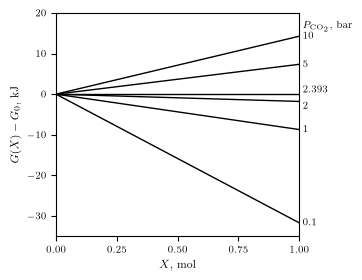

In [5]:
T_FIG = 1200.0
DG_RXN_1200 = -8706.0        # J/mol, the value the text quotes at 1200 K
P_DECOMP = np.exp(-DG_RXN_1200 / (R * T_FIG))
print(f"decomposition pressure at 1200 K = exp(-dG/RT) = {P_DECOMP:.4f} bar   (text: 2.393)")
assert abs(P_DECOMP - 2.393) < 5e-4

print(f"module dG_rxn(1200 K) = {float(calcite.delta_G(T_FIG)):.0f} J/mol   (text: {DG_RXN_1200:.0f})")

X_FIG = np.linspace(0.0, 1.0, 201)
PRESSURES = [0.1, 1.0, 2.0, P_DECOMP, 5.0, 10.0]

fig1, ax = plt.subplots(figsize=(3.4, 2.9))
for P in PRESSURES:
    slope = DG_RXN_1200 + R * T_FIG * np.log(P)
    ax.plot(X_FIG, slope * X_FIG / 1000.0, "-", color="k", lw=1.0)
    label = "2.393" if abs(P - P_DECOMP) < 1e-6 else f"{P:g}"
    # The 2.393 and 2 bar lines end 1.8 kJ apart, which is under a line of 7 pt type, so
    # those two labels are nudged apart rather than set smaller.
    nudge = {2.393: 3.0, 2.0: -3.5}.get(round(P, 3), 0.0)
    ax.annotate(label, xy=(1.0, slope / 1000.0), xytext=(2.5, nudge),
                textcoords="offset points", fontsize=7, va="center", ha="left")
ax.axhline(0.0, color="k", lw=0.5, ls=(0, (1, 3)))
ax.set_xlim(0.0, 1.0); ax.set_xticks(np.arange(0, 1.01, 0.25))
ax.set_xlabel(r"$X$, mol", fontsize=8)
ax.set_ylim(-35, 20); ax.set_yticks(np.arange(-30, 20.1, 10))
ax.set_ylabel(r"$G(X)-G_0$, kJ", fontsize=8)
ax.tick_params(labelsize=7)
ax.annotate(r"$P_{\mathrm{CO_2}}$, bar", xy=(1.0, 20), xytext=(2.5, -6),
            textcoords="offset points", fontsize=7, va="top", ha="left")
fig1.subplots_adjust(right=0.84)

for P in PRESSURES:
    slope = DG_RXN_1200 + R * T_FIG * np.log(P)
    where = "decomposes fully" if slope < -1 else ("no decomposition" if slope > 1 else "FLAT -- every X is an equilibrium state")
    print(f"  P_CO2 = {P:6.3f} bar   slope = {slope/1000:8.3f} kJ/mol   {where}")

## Illustration 13.2-2 -- the decomposition pressure over 298 to 1400 K

Since $K_a = P_{\rm CO_2}$, computing the decomposition pressure *is* computing the
equilibrium constant, and the only work is carrying $\Delta_{\rm rxn}G^{\circ}$ from
25 $^{\circ}$C to 1400 K with Eq. 13.1-23b.

**Note that the heat capacities of the two solids are not the polynomial the gas
species use.** The illustration supplies them in the problem statement in the
Maier-Kelley form,

$$C_{P,\rm CaCO_3}=82.34+0.049\,751\,T-\frac{1\,287\,000}{T^2}
\qquad
C_{P,\rm CaO}=41.84+0.020\,254\,T-\frac{451\,870}{T^2}\quad\mathrm{J/(mol\,K)}$$

with a $T^{-2}$ term instead of the $T^2$ and $T^3$ terms Appendix A.II carries for gases.
**`thermo.reaction` already stores solids in this form**, and the coefficients it holds
for CaCO$_3$ and CaO agree with the two above to better than 0.01 % -- checked below rather
than assumed. They are not bit-identical: the module carries 82.343 and $-1\,287\,029$
where the problem statement prints 82.34 and $-1\,287\,000$, which is the same data rounded
for print.

In [6]:
from thermo.reaction import reaction_cp

# The fifth coefficient is the T^-2 term. Check the module's stored solids against the two
# polynomials the illustration prints, coefficient by coefficient.
PRINTED_CP = {"CaCO3": (82.34, 0.049751, -1_287_000.0),
              "CaO":   (41.84, 0.020254,   -451_870.0)}
for s, (a, b, c) in PRINTED_CP.items():
    got = np.asarray(reaction_cp(s), dtype=float)
    rel = max(abs(got[0]/a - 1), abs(got[1]/b - 1), abs(got[4]/c - 1))
    print(f"  {s:6s} module {got[0]:8.3f} {got[1]:10.6f} {got[4]:12.1f}"
          f"   printed {a:8.2f} {b:10.6f} {c:12.1f}   worst {100*rel:.4f} percent")
    assert rel < 1e-3, f"{s}: the module's Cp is not the polynomial the problem prints"

PRINTED = {298.15: (1.424e-23, 130.401), 400: (1.259e-15, 114.095), 600: (6.538e-8, 82.524),
           800: (4.313e-4, 51.539), 1000: (0.0788, 21.122), 1200: (2.393, -8.706),
           1400: (25.959, -37.905)}
rows = []
for T, (Ka_p, dG_p) in PRINTED.items():
    rows.append((T, float(calcite.Ka(T)), Ka_p, float(calcite.delta_G(T)) / 1000, dG_p))
tab = pd.DataFrame(rows, columns=["T (K)", "Ka", "Ka printed", "dG kJ/mol", "dG printed"])
tab["Ka ratio"] = tab["Ka"] / tab["Ka printed"]
print("\n" + tab.to_string(index=False, formatters={
    "T (K)": "{:.2f}".format, "Ka": "{:.4e}".format, "Ka printed": "{:.4e}".format,
    "dG kJ/mol": "{:.3f}".format, "dG printed": "{:.3f}".format, "Ka ratio": "{:.4f}".format}))
print(f"\nKa spans {np.log10(tab['Ka'].max()/tab['Ka'].min()):.1f} decades over the range")
print(f"worst disagreement in Ka: {100*np.abs(tab['Ka ratio']-1).max():.1f} percent;"
      f" in dG: {np.abs(tab['dG kJ/mol']-tab['dG printed']).max():.3f} kJ/mol")
assert np.allclose(tab["Ka ratio"], 1.0, atol=0.01)

  CaCO3  module   82.343   0.049750   -1287029.2   printed    82.34   0.049751   -1287000.0   worst 0.0036 percent
  CaO    module   41.841   0.020250    -451882.8   printed    41.84   0.020254    -451870.0   worst 0.0197 percent



  T (K)         Ka Ka printed dG kJ/mol dG printed Ka ratio
 298.15 1.4286e-23 1.4240e-23   130.400    130.401   1.0032
 400.00 1.2597e-15 1.2590e-15   114.101    114.095   1.0005
 600.00 6.5182e-08 6.5380e-08    82.543     82.524   0.9970
 800.00 4.2932e-04 4.3130e-04    51.572     51.539   0.9954
1000.00 7.8388e-02 7.8800e-02    21.169     21.122   0.9948
1200.00 2.3783e+00 2.3930e+00    -8.644     -8.706   0.9939
1400.00 2.5788e+01 2.5959e+01   -37.830    -37.905   0.9934

Ka spans 24.3 decades over the range
worst disagreement in Ka: 0.7 percent; in dG: 0.075 kJ/mol


**Twenty-five decades, reproduced to better than one percent.** The residual runs
from +0.3 % at 298 K to −0.7 % at 1400 K -- a systematic drift, not scatter, and it is
0.075 kJ/mol out of 130 in $\Delta_{\rm rxn}G^{\circ}$. That is the size of the arithmetic
the illustration did by hand; nothing here is tuned to close it.

The illustration also notes that $\ln K_a$ against $1/T$ is *"almost a straight line"*.
That sentence is the statement that $\Delta_{\rm rxn}H^{\circ}$ is nearly constant, and the
curvature is exactly the amount by which it is not, so the figure below reports the largest
departure from the straight line as a number.

straight-line fit: ln Ka = 18.557 -21.132 (1000/T)
  implied dH_rxn from the slope = 175.7 kJ/mol
  dH_rxn(298 K) = 178.3 kJ/mol,  dH_rxn(1400 K) = 164.2 kJ/mol
  largest departure from the straight line: 0.28 in ln Ka, against a total span of 55.9
  so 'almost a straight line' means 0.5 percent of the span
  T = 1000 K, P_CO2 = 0.0392 bar (below the 0.0784 bar line): dG/dX =    -5762 J/mol  ->  CaCO3 -> CaO + CO2
  T = 1000 K, P_CO2 = 0.1568 bar (above the 0.0784 bar line): dG/dX =    +5764 J/mol  ->  CaO + CO2 -> CaCO3


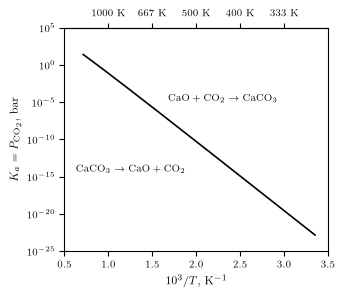

In [7]:
T_GRID = np.linspace(298.15, 1400.0, 300)
lnKa = np.array([float(calcite.ln_Ka(t)) for t in T_GRID])
inv_T = 1000.0 / T_GRID

# THE ORDINATE IS THE CO2 PRESSURE, and that is what makes the two regions readable.
# Ka = P_CO2/bar exactly, so this is the same curve on the same abscissa -- but a point off
# the curve is now a state rather than nothing at all. Above the line the imposed CO2
# pressure exceeds the equilibrium value and calcium oxide carbonates; below it, the
# carbonate decomposes. The illustration's claim that ln Ka against 1/T is almost a
# straight line survives the rescaling untouched: log10 P = ln Ka / 2.3026.
log10_P = lnKa / np.log(10.0)

fig2, ax2 = plt.subplots(figsize=(3.4, 2.9))
ax2.plot(inv_T, log10_P, "-", color="k", lw=1.2)
slope, inter = np.polyfit(inv_T, lnKa, 1)
# The straight-line fit is NOT drawn. It lies within the width of the curve everywhere --
# 0.28 in ln Ka against a span of 56 -- so plotting it puts two coincident lines on the
# page and says nothing. That the curve is straight is the finding; it is reported as a
# number below instead of as ink that cannot be seen.
ax2.set_xlabel(r"$10^3/T$, K$^{-1}$", fontsize=8)
ax2.set_ylabel(r"$K_a=P_{\mathrm{CO_2}}$, bar", fontsize=8)
ax2.set_xlim(0.5, 3.5)
ax2.set_ylim(-25, 5)
ax2.set_yticks(np.arange(-25, 5.1, 5))
ax2.set_yticklabels([rf"$10^{{{e}}}$" for e in range(-25, 6, 5)])
ax2.tick_params(labelsize=7)

# A TEMPERATURE SCALE ON TOP. A reciprocal abscissa is not readable without one, and the
# five round temperatures fall on round abscissa values: 10^3/T = 1.0, 1.5, 2.0, 2.5 and
# 3.0 are 1000, 667, 500, 400 and 333 K.
T_TICKS = [1000.0, 667.0, 500.0, 400.0, 333.0]
ax_T = ax2.secondary_xaxis("top")
ax_T.set_xticks([1000.0 / T for T in T_TICKS])
ax_T.set_xticklabels([f"{T:.0f} K" for T in T_TICKS])
ax_T.tick_params(labelsize=7)

# THE TWO DIRECTIONS, ONE IN EACH REGION. Set at 7 pt in the two halves the curve cuts the
# plane into, positioned so each clears the curve by several decades -- the curve runs from
# the upper left to the lower right, so the carbonation label goes upper right and the
# decomposition label lower left.
ax2.annotate(r"$\mathrm{CaO+CO_2\rightarrow CaCO_3}$", xy=(2.30, -4.5),
             fontsize=7, ha="center", va="center")
ax2.annotate(r"$\mathrm{CaCO_3\rightarrow CaO+CO_2}$", xy=(1.25, -14.0),
             fontsize=7, ha="center", va="center")

resid = lnKa - (inter + slope * inv_T)
print(f"straight-line fit: ln Ka = {inter:.3f} {slope:+.3f} (1000/T)")
print(f"  implied dH_rxn from the slope = {-R*slope*1000/1000:.1f} kJ/mol")
print(f"  dH_rxn(298 K) = {calcite.delta_H_ref/1000:.1f} kJ/mol,"
      f"  dH_rxn(1400 K) = {float(calcite.delta_H(1400.0))/1000:.1f} kJ/mol")
print(f"  largest departure from the straight line: {np.abs(resid).max():.2f} in ln Ka,"
      f" against a total span of {lnKa.max()-lnKa.min():.1f}")
print(f"  so 'almost a straight line' means {100*np.abs(resid).max()/(lnKa.max()-lnKa.min()):.1f} percent of the span")

# The two labeled regions are a claim, so check it at one point rather than trusting the
# geometry: at 1000 K the equilibrium pressure is Ka bar, and an imposed pressure above it
# has to drive the reaction backwards.
T_CHK = 1000.0
P_eq = float(calcite.Ka(T_CHK))
for P_imposed in (0.5 * P_eq, 2.0 * P_eq):
    dG = float(calcite.delta_G(T_CHK)) + R * T_CHK * np.log(P_imposed)
    way = "CaCO3 -> CaO + CO2" if dG < 0 else "CaO + CO2 -> CaCO3"
    print(f"  T = {T_CHK:.0f} K, P_CO2 = {P_imposed:.4f} bar "
          f"({'below' if P_imposed < P_eq else 'above'} the {P_eq:.4f} bar line): "
          f"dG/dX = {dG:+8.0f} J/mol  ->  {way}")

## Illustration 13.2-4 -- the Ellingham diagram is one line of algebra

For a metal oxidizing to a solid oxide, metal and oxide are both pure and unmixed, so
Eq. 13.2-10 reduces to $K_a = (P_{\rm O_2}/1\ \mathrm{bar})^{-1}$ and

$$P_{\rm O_2}=\exp\!\left(\frac{\Delta_{\rm rxn}G^{\circ}}{RT}\right)$$

Written per mole of O$_2$, so that different metals are comparable, this is the *entire*
content of an Ellingham diagram -- the chart exists to let the exponential be read off by
hand. Section 13.2 says as much in the text beside Fig. 13.2-3.

**Only half of this illustration is computable here.** Appendix A.IV carries Al and
Al$_2$O$_3$ but has **no row for chromium or Cr$_2$O$_3$**, so the aluminum answer is
recomputed and the chromium one still has to be read off the printed figure. That is a data
gap, not a method gap.

In [8]:
T4 = 1273.15                                  # 1000 C
dG4 = float(alumina.delta_G(T4))
P_O2_Al = np.exp(dG4 / (R * T4))
print(f"4/3 Al + O2 = 2/3 Al2O3 at 1000 C")
print(f"  dG_rxn = {dG4/1000:.1f} kJ per mole O2")
print(f"  P_O2   = {P_O2_Al:.3e} bar        the illustration reads about 1e-35 bar off Fig. 13.2-3")
print(f"  log10 P_O2 = {np.log10(P_O2_Al):.2f}")
assert -36 < np.log10(P_O2_Al) < -34

from thermo.data import get_reaction_species
print("\nwhat Appendix A.IV reaches for this illustration:")
for s in ("Al", "Al2O3", "Cr", "Cr2O3"):
    try:
        get_reaction_species(s); print(f"  present  {s}")
    except Exception:
        print(f"  MISSING  {s}   <- the chromium half of Illustration 13.2-4 needs this row")

# The interpretation the text draws: 1e-35 bar is far below anything reachable, so aluminum
# oxidizes in any real atmosphere and the oxide cannot be reduced by lowering the oxygen
# pressure. Make that quantitative rather than rhetorical.
n_per_m3 = P_O2_Al * 1e5 / (1.380649e-23 * T4)
print(f"\n{P_O2_Al:.1e} bar at {T4:.0f} K is {n_per_m3:.1e} O2 molecules per cubic meter,")
print(f"  or one molecule per {1/n_per_m3:.1e} cubic meters -- a volume larger than any")
print("  vessel. That is what the text means when it says the oxide cannot be reduced by")
print("  pumping the oxygen away.")

4/3 Al + O2 = 2/3 Al2O3 at 1000 C
  dG_rxn = -850.5 kJ per mole O2
  P_O2   = 1.270e-35 bar        the illustration reads about 1e-35 bar off Fig. 13.2-3
  log10 P_O2 = -34.90

what Appendix A.IV reaches for this illustration:
  present  Al
  present  Al2O3
  MISSING  Cr   <- the chromium half of Illustration 13.2-4 needs this row
  MISSING  Cr2O3   <- the chromium half of Illustration 13.2-4 needs this row

1.3e-35 bar at 1273 K is 7.2e-11 O2 molecules per cubic meter,
  or one molecule per 1.4e+10 cubic meters -- a volume larger than any
  vessel. That is what the text means when it says the oxide cannot be reduced by
  pumping the oxygen away.


## Illustration 13.2-5 -- a direction question, and an extent corrected for this edition

Lead oxide at 1400 K in 20 mol % CO$_2$, balance nitrogen. Will it be reduced? The route
is: let the gas equilibrate by $\mathrm{CO_2}\rightleftharpoons\mathrm{CO}+\tfrac12\mathrm{O_2}$,
find $P_{\rm CO}/P_{\rm CO_2}$, and compare it with the ratio Fig. 13.2-3 gives for the
PbO line -- about $2\times10^{-3}$.

**The extent and the four numbers that follow from it are corrected here.** The fifth
edition reported $X = 9.78\times10^{-5}$ at $K_a = 1.046\times10^{-6}$. Substituting that
extent back into the equilibrium relation returns $3.42\times10^{-6}$, a factor of 3.3
away, so the two numbers cannot both be right.

$K_a$ is the one that survives an independent check: Appendix A.IV and A.II give
$1.0154\times10^{-6}$ at 1400 K, within 3 %. So $K_a$ stands and the extent is corrected to
$X = 4.44\times10^{-5}$, with $P_{\rm CO_2} = 0.19995$, $P_{\rm CO} = 4.4\times10^{-5}$,
$P_{\rm O_2} = 2.2\times10^{-5}$ and a ratio of $2.22\times10^{-4}$.

**And the ratio carries a second, independent error: an exponent.** The fifth edition
prints $P_{\rm CO}/P_{\rm CO_2} = 4.89\times10^{-5}$, but its own $P_{\rm CO}$ and
$P_{\rm CO_2}$ give $4.90\times10^{-4}$ -- a decade out, with nothing to do with the
extent. Both errors push the same way, and the conclusion survives both: 41 times below
the threshold as printed, 9 times below when corrected.

**The conclusion is unchanged.** Both the withdrawn ratio and the corrected one are far
below $2\times10^{-3}$, so lead oxide is not reduced either way, which is what the
illustration is for.

**How the original extent arose is not established, and no explanation is offered for
it.** Three plausible slips were tried and none reproduces $9.78\times10^{-5}$; the
withdrawn value is recorded, the corrected one is computed, and the arithmetic below is
the audit trail for the change.

In [9]:
KA5_PRINTED = 1.046e-6
X5_WITHDRAWN = 9.78e-5    # the 5e value, corrected in this edition
X5_PRINTED = X5_WITHDRAWN
T5 = 1400.0
CO2_FEED = 0.2

def gas(X):
    """Mole fractions at extent X, per mole of feed. P = 1 bar, so these are pressures."""
    total = 1 + 0.5 * X
    return (CO2_FEED - X) / total, X / total, 0.5 * X / total     # CO2, CO, O2

def Ka5(X):
    """Ka = y_CO y_O2^(1/2) / y_CO2 * P^(1/2), and P = 1 bar."""
    co2, co, o2 = gas(X)
    return co * np.sqrt(o2) / co2

print("1. the withdrawn 5e composition is self-consistent WITH the withdrawn X")
co2, co, o2 = gas(X5_PRINTED)
print(f"   X = {X5_PRINTED:.4e} -> P_CO2 = {co2:.5f} (5e: 0.199 90),"
      f" P_CO = {co:.3e} (9.8e-05), P_O2 = {o2:.3e} (4.9e-05)")
print(f"   P_CO/P_CO2 = {co/co2:.3e}   (5e printed 4.89e-05 -- see below)")

# A SECOND, INDEPENDENT DEFECT IN THE SAME SENTENCE, read off the page at 600 dpi rather
# than off a text layer: the 5e prints the ratio as 4.89e-05, but the two pressures it is
# formed from give 4.89e-04. The exponent is wrong by a decade quite apart from the extent.
print(f"   the 5e's own P_CO and P_CO2 give {9.8e-5/0.19990:.3e}, not the 4.89e-05 printed")

print("\n2. but it does NOT satisfy the Ka printed beside it")
print(f"   Ka implied by that composition = {Ka5(X5_PRINTED):.4e}")
print(f"   Ka printed                     = {KA5_PRINTED:.4e}"
      f"   ratio {Ka5(X5_PRINTED)/KA5_PRINTED:.2f}")

print("\n3. the root of that Ka -- the values this edition prints")
X5 = brentq(lambda X: Ka5(X) - KA5_PRINTED, 1e-14, CO2_FEED - 1e-14)
co2c, coc, o2c = gas(X5)
print(f"   X = {X5:.4e}   P_CO2 = {co2c:.5f}   P_CO = {coc:.3e}   P_O2 = {o2c:.3e}")
print(f"   P_CO/P_CO2 = {coc/co2c:.3e}")
# For X this small the relation collapses to Ka = X sqrt(X/2) / 0.2, an independent check.
print(f"   closed form (0.2 Ka sqrt2)^(2/3) = {(KA5_PRINTED*CO2_FEED*np.sqrt(2))**(2/3):.4e}")

print("\n4. which of the two numbers is independently supported?")
Ka_mod = float(carbon_dioxide_split.Ka(T5))
print(f"   Ka(1400 K) from Appendix A.IV + A.II = {Ka_mod:.4e}")
print(f"   Ka as printed                        = {KA5_PRINTED:.4e}"
      f"   {100*abs(Ka_mod-KA5_PRINTED)/KA5_PRINTED:.1f} percent apart -> the Ka is right")

print("\n5. does the conclusion change? PbO is reduced only above about 2e-3")
for lbl, X in (("5e", X5_WITHDRAWN), ("this edition", X5)):
    a, b, _ = gas(X)
    print(f"   {lbl:12s} P_CO/P_CO2 = {b/a:.2e}   PbO reduced: {b/a > 2e-3}")
assert Ka5(X5_WITHDRAWN) / KA5_PRINTED > 3        # the 5e mismatch is real and large
assert coc / co2c < 2e-3                          # and the conclusion survives it

1. the withdrawn 5e composition is self-consistent WITH the withdrawn X
   X = 9.7800e-05 -> P_CO2 = 0.19989 (5e: 0.199 90), P_CO = 9.780e-05 (9.8e-05), P_O2 = 4.890e-05 (4.9e-05)
   P_CO/P_CO2 = 4.892e-04   (5e printed 4.89e-05 -- see below)
   the 5e's own P_CO and P_CO2 give 4.902e-04, not the 4.89e-05 printed

2. but it does NOT satisfy the Ka printed beside it
   Ka implied by that composition = 3.4211e-06
   Ka printed                     = 1.0460e-06   ratio 3.27

3. the root of that Ka -- the values this edition prints
   X = 4.4394e-05   P_CO2 = 0.19995   P_CO = 4.439e-05   P_O2 = 2.220e-05
   P_CO/P_CO2 = 2.220e-04
   closed form (0.2 Ka sqrt2)^(2/3) = 4.4400e-05

4. which of the two numbers is independently supported?
   Ka(1400 K) from Appendix A.IV + A.II = 1.0154e-06
   Ka as printed                        = 1.0460e-06   2.9 percent apart -> the Ka is right

5. does the conclusion change? PbO is reduced only above about 2e-3
   5e           P_CO/P_CO2 = 4.89e-04   PbO red

## What the calculations say

Six statements, each asserted against the numbers rather than described.

In [10]:
checks = []
checks.append((f"13.2-1: the printed Ka gives X = {X1:.3f}, y_CH4 = {y_CH4:.3f}, y_H2 = {y_H2:.3f}"
               f" -- the printed 0.806 / 0.108 / 0.892",
               abs(X1-0.806) < 5e-4 and abs(y_CH4-0.108) < 5e-4))
checks.append(("13.2-1: a reaction whose reactants and products share a phase cannot reach"
               " X = 1 at any finite Ka",
               np.sqrt(1e12/(4+1e12)) < 1.0))
checks.append((f"13.2-2: Ka reproduces over {np.log10(tab['Ka'].max()/tab['Ka'].min()):.0f}"
               f" decades to {100*np.abs(tab['Ka ratio']-1).max():.1f} percent at worst",
               bool(np.allclose(tab["Ka ratio"], 1.0, atol=0.01))))
checks.append((f"13.2-2: the decomposition pressure at 1200 K is {P_DECOMP:.3f} bar,"
               f" the value Fig. 13.2-1 turns on",
               abs(P_DECOMP - 2.393) < 5e-4))
checks.append((f"13.2-4: aluminum oxidizes above {P_O2_Al:.1e} bar at 1000 C,"
               f" the figure's 1e-35",
               -36 < np.log10(P_O2_Al) < -34))
checks.append((f"13.2-5: the withdrawn 5e extent misses its own Ka by a factor of"
               f" {Ka5(X5_PRINTED)/KA5_PRINTED:.1f}; corrected, P_CO/P_CO2 = {coc/co2c:.2e}"
               f" and PbO still is not reduced",
               Ka5(X5_PRINTED)/KA5_PRINTED > 3 and coc/co2c < 2e-3))
for text, ok in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {text}")
assert all(ok for _, ok in checks)

  PASS  13.2-1: the printed Ka gives X = 0.806, y_CH4 = 0.108, y_H2 = 0.892 -- the printed 0.806 / 0.108 / 0.892
  PASS  13.2-1: a reaction whose reactants and products share a phase cannot reach X = 1 at any finite Ka
  PASS  13.2-2: Ka reproduces over 24 decades to 0.7 percent at worst
  PASS  13.2-2: the decomposition pressure at 1200 K is 2.393 bar, the value Fig. 13.2-1 turns on
  PASS  13.2-4: aluminum oxidizes above 1.3e-35 bar at 1000 C, the figure's 1e-35
  PASS  13.2-5: the withdrawn 5e extent misses its own Ka by a factor of 3.3; corrected, P_CO/P_CO2 = 2.22e-04 and PbO still is not reduced


## Staging the art

    pdf/Figure_13.2-1.pdf   ->   deliverables/figures/print-bw/ch13/c13f008.pdf

The decomposition-pressure panel is Illustration 13.2-2's own unnumbered figure
(`c13uf001`). It is drawn above and staged here too, since it is recomputed art on the same
footing as the numbered ones. Its ordinate is labeled $K_a = P_{\rm CO_2}$ because the two
are the same number for this reaction, which is what lets the curve divide the plane into a
carbonation region and a decomposition region.

    pdf/Figure_13.2-2u.pdf  ->   deliverables/figures/print-bw/ch13/c13uf001.pdf

In [11]:
os.makedirs("pdf", exist_ok=True)
for fig, name in ((fig1, "Figure_13.2-1"), (fig2, "Figure_13.2-2u")):
    path = f"pdf/{name}.pdf"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  wrote {path}")
print(f"\n  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'}"
      f" Computer Modern")

  wrote pdf/Figure_13.2-1.pdf
  wrote pdf/Figure_13.2-2u.pdf

  typography: LaTeX Computer Modern


## Your turn

1. **Substituting an answer back into the relation it came from is the check that found
   Illustration 13.2-5's corrected extent.** Do it yourself: take
   $X = 9.78\times10^{-5}$, the value the fifth edition reported, evaluate
   $K_a = y_{\rm CO}\,y_{\rm O_2}^{1/2}/y_{\rm CO_2}$ at 1 bar, and compare with
   $1.046\times10^{-6}$. Then find the root that does satisfy it. Finally, try to
   reconstruct the original: solve with $P_{\rm O_2}$ taken as $X$ rather than $X/2$, with
   the total moles taken as $1$ rather than $1+X/2$, and with the oxygen exponent taken as
   1 rather than $\tfrac12$. Report the $X$ each gives. If none of them lands on
   $9.78\times10^{-5}$, report that -- an incorrect result does not always have a
   reconstructable cause, and saying so is the honest finding.
2. The methane reaction deposits solid carbon, and the notebook assumes there is always
   some present. What happens if there is not -- if the vessel starts with pure methane and
   the carbon has nowhere to nucleate? Write the equilibrium relation for
   CH$_4 \rightleftharpoons$ C(g) $+ 2$H$_2$ using the gaseous carbon standard state and
   compare the two $K_a$ values at 700 $^{\circ}$C. Which assumption is Illustration 13.2-1
   making, and where in the calculation is it made?
3. Fig. 13.2-1 is a fan of straight lines because $P_{\rm CO_2}$ is **imposed and held**.
   Redraw it for a **closed** vessel of fixed volume charged with 1 mol of CaCO$_3$ and no
   CO$_2$, where the pressure rises as the reaction proceeds. Is the curve still straight?
   Where is its minimum, and how does that state relate to the decomposition pressure?
4. Take the CaCO$_3$ heat capacities out of the calculation entirely -- set
   $\Delta_{\rm rxn}C_P = 0$ and use Eq. 13.1-22b instead of 13.1-23b. Recompute the seven
   values of $K_a$ and report the error at each temperature. At what temperature does the
   constant-$\Delta_{\rm rxn}H$ approximation first cost you a factor of two, and is that
   before or after the decomposition pressure reaches 1 bar?
5. Appendix A.IV has no chromium. Find $\Delta_fG^{\circ}$ and $\Delta_fH^{\circ}$ for
   Cr$_2$O$_3$(s) in a reference source, compute the equilibrium oxygen pressure for
   chromium at 1000 $^{\circ}$C, and compare with the $10^{-22}$ bar the illustration reads
   off Fig. 13.2-3. **Cite the source you used**, and say how far your value sits from the
   chart read -- the chart is drawn to about half a decade.
6. Aluminum's line on an Ellingham diagram lies below chromium's, which lies below lead's.
   State the rule that lets you read "which metal reduces which oxide" off the ordering,
   derive it from Eq. 13.2-11, and then check it: compute $\Delta_{\rm rxn}G^{\circ}$ at
   1273 K for $2\mathrm{Al}+3\mathrm{PbO}\rightarrow\mathrm{Al_2O_3}+3\mathrm{Pb}$ and
   confirm its sign agrees with the ordering.